# 1 - Descritivo — Caracterização Quantitativa do Dataset

## Objetivo

Caracterizar quantitativamente o dataset: cobertura, escala, dispersão e padrão de ausência de cada variável, recortados por estação e por ano.

## Pergunta que responde

> Quanto dado temos por variável, por estação e por ano? Onde estão os buracos?

## Posição na Etapa 1 — EDA

Este é o notebook **1 de 6** da EDA. Ele responde à primeira das 5 perguntas-meta da etapa:

1. **Quais variáveis têm boa cobertura e quais são críticas?** ← *este notebook*
2. Quais variáveis são simétricas vs assimétricas? → `02_distribuicoes.ipynb`
3. Quais pares são correlacionados? → `03_correlacoes.ipynb`
4. Há padrão temporal? → `04_temporal.ipynb`
5. As estações são distintas? → `05_estacoes.ipynb`
6. A censura é estruturada? → `06_lds.ipynb`

## Resumo executivo

- Sete variáveis apresentam cobertura ≥ 95% (DBO, OD, Fósforo Total, Condutividade, pH, Turbidez e Temperatura da Água); três são críticas com mais de 75% de dados ausentes: Sólidos Suspensos Totais (76%), Cianobactérias (80%) e Microcistinas (92%).
- Quase todas as variáveis exibem assimetria forte (|skew| > 1); os casos mais graves são Fósforo Total (13,4), Turbidez (9,5), Condutividade (9,2) e Nitrato (8,7) — candidatos prioritários à transformação logarítmica em `02_distribuicoes.ipynb`.
- Nitrato é a única variável com censura estruturada expressiva (22% dos valores observados); JC341 e MR363 são estações descontinuadas após 2015 (10 e 8 coletas no total); 2020 foi um ano de monitoramento mínimo. Nenhuma linha do dataset está completa nas 13 variáveis, mas 644 linhas (98%) têm ao menos 4 variáveis preenchidas.


## Setup

Importações, configurações e constantes usadas em todo o notebook. Os caminhos são relativos a este notebook (`Code/2 - EDA/01_descritivo.ipynb`).

In [30]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

# Caminhos
DATA_PATH   = Path("../../Data/IntermediaryData/WaterQualityInitialData.xlsx")
OUTPUT_BASE = Path("../../Data/Figures/01_EDA")
FIG_DIR     = OUTPUT_BASE / "figuras"
TAB_DIR     = OUTPUT_BASE / "tabelas"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# Variáveis numéricas de interesse (mesma ordem do dataset tratado)
VARS = [
    "DBO", "OD", "Nitrato", "Nitrogênio Amoniacal Total", "Fósforo Total",
    "Condutividade", "pH", "Turbidez", "Temperatura da Água",
    "Sólidos Suspensos Totais", "Coliformes Termotolerantes",
    "Cianobacterias", "Microcistinas",
]
LD_COLS = [f"{v}_LD" for v in VARS]

## Carregamento

Leitura do dataset consolidado produzido pelo notebook `Code/1 - FetchAndTreatRawData/treat_raw_data.ipynb`.

Esperado: **657 linhas × 30 colunas** (4 base + 13 pares variável/LD).

In [31]:
df = pd.read_excel(DATA_PATH)
print(f"Shape: {df.shape}")

Shape: (657, 30)


In [32]:
df.head()

,Local,Codigo Local,Data,Ano,DBO_LD,DBO,OD_LD,OD,Nitrato_LD,Nitrato,Nitrogênio Amoniacal Total_LD,Nitrogênio Amoniacal Total,Fósforo Total_LD,Fósforo Total,Condutividade_LD,Condutividade,pH_LD,pH,Turbidez_LD,Turbidez,Temperatura da Água_LD,Temperatura da Água,Sólidos Suspensos Totais_LD,Sólidos Suspensos Totais,Coliformes Termotolerantes_LD,Coliformes Termotolerantes,Cianobacterias_LD,Cianobacterias,Microcistinas_LD,Microcistinas
0,Lagoa de Camorim,CM320,2012-01-12,2012,NaN,14.0,NaN,4.8,NaN,0.04,NaN,0.11,NaN,0.69,NaN,3460.0,NaN,8.0,NaN,136.0,NaN,26.0,NaN,60.0,NaN,23000.0,NaN,NaN,NaN,NaN
1,Lagoa de Camorim,CM320,2012-02-09,2012,NaN,40.0,NaN,0.4,<,0.01,NaN,4.10,NaN,0.62,NaN,25400.0,NaN,7.3,NaN,2.3,NaN,NaN,NaN,38.0,NaN,2000.0,NaN,0.401,NaN,NaN
2,Lagoa de Camorim,CM320,2012-03-08,2012,NaN,32.0,NaN,0.0,NaN,0.07,NaN,5.20,NaN,0.70,NaN,5300.0,NaN,6.9,NaN,29.0,NaN,22.0,NaN,53.0,>,160000.0,NaN,36.800,NaN,NaN
3,Lagoa de Camorim,CM320,2012-04-12,2012,NaN,20.0,NaN,3.2,NaN,0.07,NaN,2.20,NaN,1.10,NaN,8160.0,NaN,7.0,NaN,90.0,NaN,27.0,NaN,83.0,NaN,240000.0,NaN,47.340,NaN,NaN
4,Lagoa de Camorim,CM320,2012-05-17,2012,NaN,16.0,NaN,3.4,NaN,0.01,NaN,2.96,NaN,1.10,NaN,5630.0,NaN,7.6,NaN,35.0,NaN,22.0,NaN,39.0,NaN,54000.0,NaN,NaN,NaN,NaN


**Sanidade:**

- Linhas/colunas batem com o esperado.
- `Data` é `datetime64`; `Ano` é integer/string (depende do output do tratamento); variáveis numéricas em `float`; colunas `_LD` em `object`/`string`.

Se algum tipo estiver fora do esperado, voltar ao notebook de tratamento.

## 1. Estatísticas globais por variável

Para cada variável, calcula contagem, missing, censurado, média, desvio, quartis, skewness e kurtosis. O resultado é persistido em `Data/Pipeline/01_EDA/tabelas/descritivo_global.csv`.

In [33]:
def descritivo_completo(df: pd.DataFrame, vars_: list[str], ld_cols: list[str]) -> pd.DataFrame:
    """Retorna DataFrame com estatísticas descritivas estendidas por variável.

    Colunas: n_total, n_obs, n_missing, pct_missing, n_censurado, pct_censurado,
    mean, std, min, q25, median, q75, max, skew, kurtosis.
    """
    rows = []
    n = len(df)
    for v, ld in zip(vars_, ld_cols):
        s = df[v]
        ld_s = df[ld] if ld in df.columns else pd.Series([], dtype="object")
        n_missing = int(s.isna().sum())
        n_obs = n - n_missing
        n_censurado = int(ld_s.astype("string").isin(["<", ">"]).sum())
        desc = s.describe()
        rows.append({
            "variavel":      v,
            "n_total":       n,
            "n_obs":         n_obs,
            "n_missing":     n_missing,
            "pct_missing":   round(n_missing / n if n else np.nan, 2)*100,
            "n_censurado":   n_censurado,
            "pct_censurado": round(n_censurado / n_obs if n_obs else np.nan, 2)*100,
            "mean":          desc.get("mean"),
            "std":           desc.get("std"),
            "min":           desc.get("min"),
            "q25":           desc.get("25%"),
            "median":        desc.get("50%"),
            "q75":           desc.get("75%"),
            "max":           desc.get("max"),
            "skew":          s.skew(),
            "kurtosis":      s.kurtosis(),
        })
    return pd.DataFrame(rows).set_index("variavel")


tab_global = descritivo_completo(df, VARS, LD_COLS)
tab_global.to_csv(TAB_DIR / "descritivo_global.csv", float_format="%.4g")
tab_global

,n_total,n_obs,n_missing,pct_missing,n_censurado,pct_censurado,mean,std,min,q25,median,q75,max,skew,kurtosis
variavel,,,,,,,,,,,,,,,
DBO,657,642,15,2.0,15,2.0,16.640249,14.567509,0.000,8.00000,14.0000,20.0000,168.000,3.774478,26.036292
OD,657,635,22,3.0,6,1.0,5.179858,3.849349,0.000,2.28000,4.4400,7.1100,24.000,1.190609,1.863571
Nitrato,657,337,320,49.0,74,22.0,0.181691,0.785844,0.010,0.01000,0.0300,0.0700,10.000,8.683852,88.903525
Nitrogênio Amoniacal Total,657,497,160,24.0,11,2.0,5.009477,5.946474,0.000,1.33000,3.6200,6.3800,46.000,3.393398,15.905322
Fósforo Total,657,624,33,5.0,0,0.0,7.745769,83.298566,0.030,0.63750,0.9550,1.3525,1200.000,13.375227,182.537088
Condutividade,657,635,22,3.0,0,0.0,19192.749764,19612.461997,12.000,7340.00000,15280.0000,29050.0000,370061.000,9.247846,160.709982
pH,657,639,18,3.0,0,0.0,7.870125,0.601853,6.000,7.48000,7.8000,8.2000,10.500,0.707894,1.184858
Turbidez,657,631,26,4.0,0,0.0,39.771902,85.773042,0.450,8.08500,18.0000,44.2750,1310.000,9.541697,114.970872
Temperatura da Água,657,629,28,4.0,0,0.0,24.782671,3.229680,16.000,22.20000,24.1000,27.0000,36.000,0.242927,-0.236355


**Como ler a tabela:**

- **`pct_missing` < 5%** → variável "robusta" para análise direta.
- **`pct_missing` > 50%** → variável crítica; sample size efetivo cai bastante.
- **|`skew`| > 1** → assimetria forte; candidata a log/Box-Cox em `02_distribuicoes.ipynb`.
- **`kurtosis` > 3** → cauda pesada; presença de outliers extremos.
- **`pct_censurado` > 10%** → censura estruturada; `_LD` entrará como feature explícita na GAIN (Etapa 2).

**Achados específicos:**

- **Variáveis robustas** (pct_missing ≤ 5%): DBO (2%), OD (3%), Condutividade (3%), pH (3%), Turbidez (4%), Temperatura da Água (4%) e Fósforo Total (5%). Adequadas para análise direta e como base do modelo.
- **Variáveis intermediárias** (5–50%): Nitrogênio Amoniacal Total (24%), Coliformes Termotolerantes (25%) e Nitrato (49%). Nitrato apresenta distribuição temporal irregular — ausente em 2013, 2014 e 2020.
- **Variáveis críticas** (pct_missing > 50%): Sólidos Suspensos Totais (76%), Cianobactérias (80%) e Microcistinas (92%). Para estas, a imputação é estritamente necessária e a incerteza do modelo será maior.
- **Assimetria mais grave** (|skew| > 3): Fósforo Total (13,4), Turbidez (9,5), Condutividade (9,2), Nitrato (8,7), Nitrogênio Amoniacal Total (3,4), DBO (3,8), Cianobactérias (3,0) e Coliformes Termotolerantes (2,9). Todas candidatas à transformação em `02_distribuicoes.ipynb`. Temperatura da Água (skew = 0,24) e pH (0,71) são as únicas distribuições próximas da simetria.
- **Censura estruturada**: apenas Nitrato ultrapassa o limiar de 10% (22% dos valores observados censurados pelo limite de detecção inferior). Cianobactérias (8%) e Microcistinas (8%) estão próximas do limiar, mas com amostra muito reduzida; merecem atenção em `06_lds.ipynb`.


## 2. Cobertura por ano

Heatmap mostrando, para cada (variável, ano), o **percentual de amostras com dado preenchido**. Anos com baixa cobertura geral indicam períodos de monitoramento reduzido; linhas escuras indicam descontinuidade de um parâmetro.

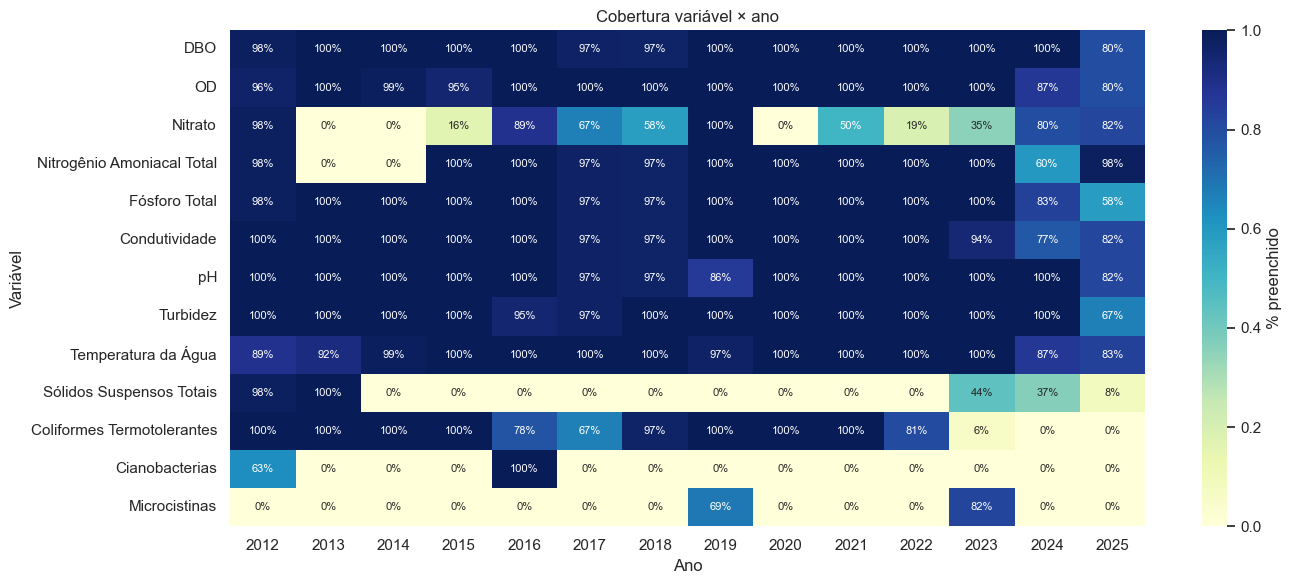

In [34]:
def cobertura_pivot(df: pd.DataFrame, vars_: list[str], group_col: str) -> pd.DataFrame:
    """Fração de não-NaN por grupo, transposta para variáveis nas linhas."""
    return df.groupby(group_col)[vars_].apply(lambda g: g.notna().mean()).T


pivot_ano = cobertura_pivot(df, VARS, "Ano")

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_ano,
    annot=True, fmt=".0%",
    cmap="YlGnBu", vmin=0, vmax=1,
    cbar_kws={"label": "% preenchido"},
    annot_kws={"size": 8},
    ax=ax,
)
ax.set_title("Cobertura variável × ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Variável")
plt.tight_layout()
plt.savefig(FIG_DIR / "descritivo_cobertura.png", dpi=150)
plt.show()

**Como interpretar:**

- **Colunas verticais escuras** → ano com cobertura ruim em várias variáveis (monitoramento reduzido).
- **Linhas horizontais escuras** → variável com cobertura intermitente (provável mudança de metodologia ou parâmetro descontinuado).
- **Bordas abruptas** (início/fim brusco de uma variável) → reflete adição/remoção de parâmetros pela rede.

**Achados específicos:**

- **2020** foi o ano de monitoramento mais reduzido: apenas 1 coleta por estação ativa, provável impacto da pandemia de COVID-19. A cobertura das variáveis individuais permanece alta nas linhas existentes, mas o esforço amostral total foi mínimo.
- **Sólidos Suspensos Totais** apresentam lacuna de aproximadamente 9 anos: medidos em 2012–2013, ausentes de 2014 a 2022 e retomados em 2023–2025 com cobertura parcial (44% e 37%).
- **Nitrato** estava ausente em 2013 e 2014 (cobertura 0%), com cobertura muito baixa em 2015 (16%) e irregular nos anos seguintes. O parâmetro só foi coletado de forma consistente a partir de 2019.
- **Coliformes Termotolerantes** apresentam queda abrupta de 100% (2019) para 6% em 2023 e zero em 2024–2025, indicando descontinuação do parâmetro na rede de monitoramento.
- **Cianobactérias** foram coletadas apenas em 2012 (63%) e 2016 (100%); completamente ausentes nos 12 anos restantes do período.
- **Microcistinas** aparecem apenas em 2019 (69%) e 2023 (82%), com cobertura zero em todos os outros anos.


## 3. Cobertura por estação

Mesmo pivot, agora variável × `Codigo Local`. As 8 estações pertencem à mesma rede e deveriam ter cobertura comparável; diferenças >20% em uma variável entre estações sinalizam priorização ou indisponibilidade local.

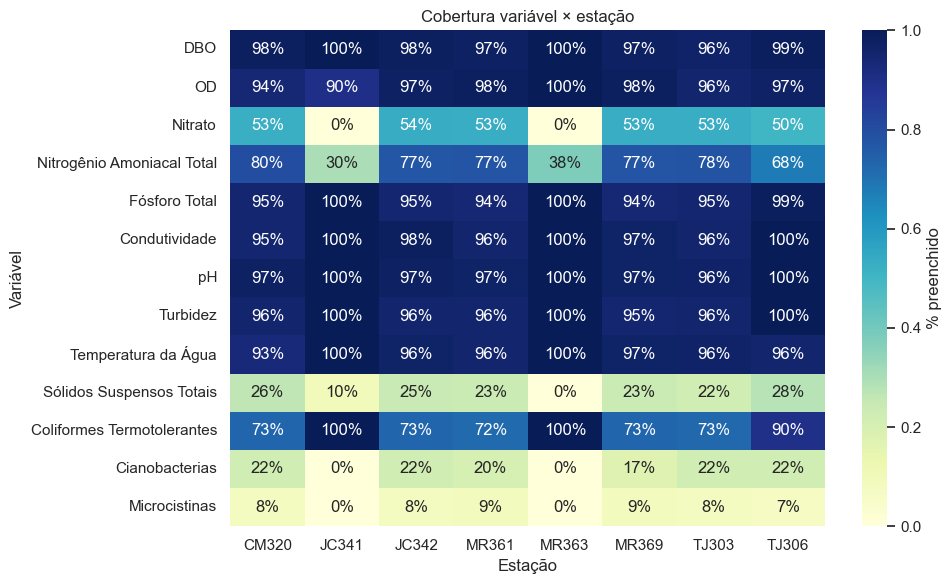

In [35]:
pivot_estacao = cobertura_pivot(df, VARS, "Codigo Local")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot_estacao,
    annot=True, fmt=".0%",
    cmap="YlGnBu", vmin=0, vmax=1,
    cbar_kws={"label": "% preenchido"},
    ax=ax,
)
ax.set_title("Cobertura variável × estação")
ax.set_xlabel("Estação")
ax.set_ylabel("Variável")
plt.tight_layout()
plt.savefig(FIG_DIR / "descritivo_cobertura_estacao.png", dpi=150)
plt.show()

**Como interpretar:**

- Cobertura uniforme entre estações → padrão de coleta consistente.
- Estações com cobertura sistematicamente menor contribuem menos para o sample size efetivo da GAIN.

**Achados específicos:**

- As estações CM320, JC342, MR361, MR369 e TJ303 apresentam padrão de cobertura homogêneo nas variáveis principais (≥ 93%), confirmando consistência do esforço amostral entre elas.
- **JC341 e MR363** diferem sistematicamente das demais: cobertura zero em Nitrato, Cianobactérias e Microcistinas; muito baixa em Nitrogênio Amoniacal Total (30% e 38% respectivamente) e Sólidos Suspensos Totais (10% e 0%). Essas estações foram descontinuadas após 2015 e têm representatividade limitada para o modelo.
- **TJ306** apresenta cobertura razoável nas variáveis principais, mas foi descontinuada a partir de 2024. Com apenas 68 coletas no total — bem abaixo das ~114 das demais estações ativas —, sua contribuição para o treinamento é menor.
- **Sólidos Suspensos Totais**: cobertura entre 22–28% nas estações ativas principais; MR363 sem nenhum registro (0%).


## 4. Esforço amostral por estação × ano

Crosstab do **número de coletas** por (estação, ano). Diferente das duas seções anteriores: aqui não é cobertura por variável, é contagem total de linhas. Lacunas (células com 0) marcam descontinuidade temporal.

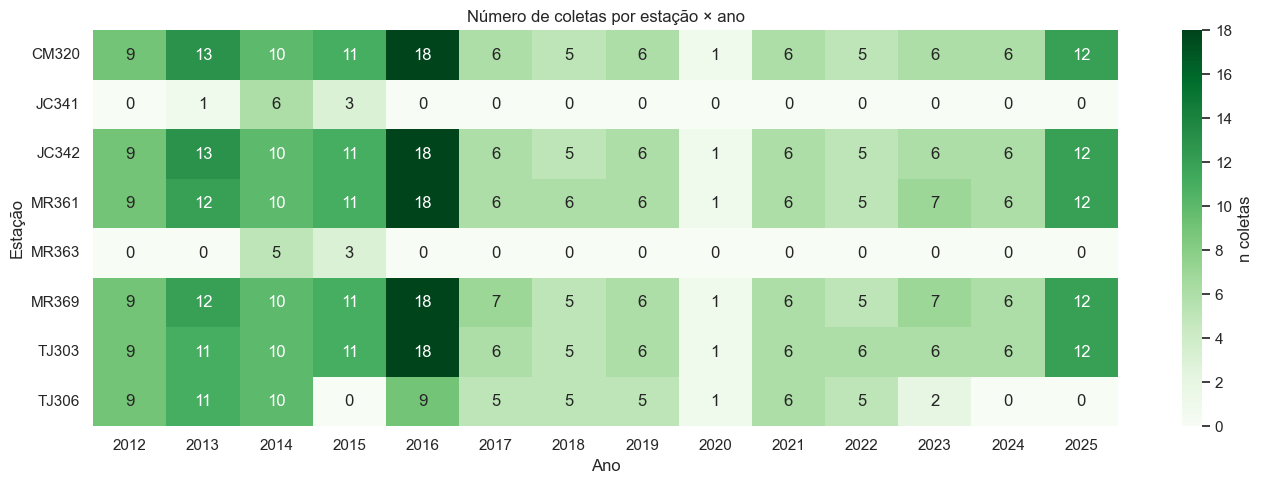

Ano,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Codigo Local,,,,,,,,,,,,,,
CM320,9,13,10,11,18,6,5,6,1,6,5,6,6,12
JC341,0,1,6,3,0,0,0,0,0,0,0,0,0,0
JC342,9,13,10,11,18,6,5,6,1,6,5,6,6,12
MR361,9,12,10,11,18,6,6,6,1,6,5,7,6,12
MR363,0,0,5,3,0,0,0,0,0,0,0,0,0,0
MR369,9,12,10,11,18,7,5,6,1,6,5,7,6,12
TJ303,9,11,10,11,18,6,5,6,1,6,6,6,6,12
TJ306,9,11,10,0,9,5,5,5,1,6,5,2,0,0


In [36]:
crosstab = pd.crosstab(df["Codigo Local"], df["Ano"])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    crosstab,
    annot=True, fmt="d",
    cmap="Greens",
    cbar_kws={"label": "n coletas"},
    ax=ax,
)
ax.set_title("Número de coletas por estação × ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Estação")
plt.tight_layout()
plt.savefig(FIG_DIR / "descritivo_esforco_amostral.png", dpi=150)
plt.show()
crosstab

**Como interpretar:**

- Células `0` → estação não foi amostrada naquele ano. Relevante para a Etapa 2 ao decidir features temporais e splits.
- Estações com esforço amostral muito baixo (< ~10 coletas no histórico inteiro) podem ter representatividade limitada — verificar `JC341` e `MR363`.

**Achados específicos:**

- **JC341** (10 coletas) e **MR363** (8 coletas) estiveram ativas apenas entre 2013–2015, sem nenhum registro nos demais 9 anos do período. São estações descontinuadas e de representatividade muito limitada.
- **TJ306** foi descontinuada a partir de 2024 (zero coletas em 2024 e 2025), totalizando apenas 68 coletas — bem abaixo das ~114 das demais estações ativas.
- **2020** foi o ano com menor esforço amostral: somente 1 coleta por estação ativa, contra uma média de ~6 por estação nos demais anos. O período coincide com a pandemia de COVID-19.
- As estações CM320, JC342, MR361, MR369 e TJ303 são as mais representativas, com 113–115 coletas cada ao longo de 2012–2025, sustentando o treinamento e a validação do modelo.


## 5. Sample size efetivo da GAIN

A GAIN não exige que todas as variáveis estejam preenchidas — a máscara `M` cobre isso. Mas para análises *downstream* (e para a Etapa 5), interessa saber **quantas linhas existem com pelo menos `k` variáveis presentes**. Conforme `k` cresce, o sample size cai.

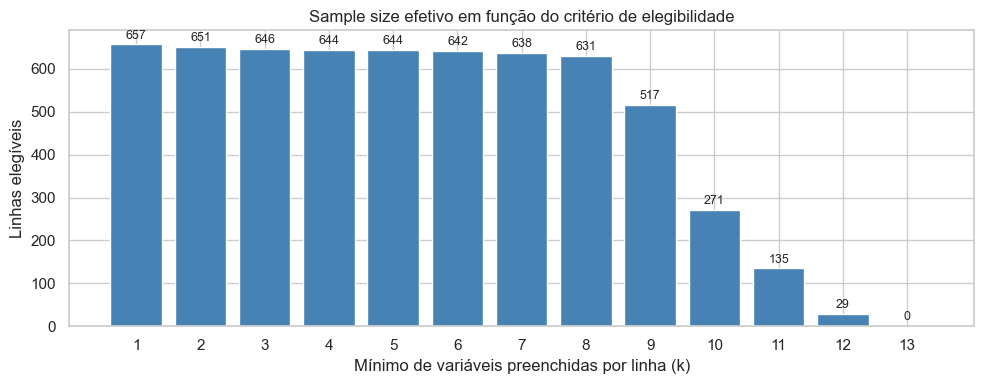

k_vars_presentes_min
1     657
2     651
3     646
4     644
5     644
6     642
7     638
8     631
9     517
10    271
11    135
12     29
13      0
Name: n_linhas, dtype: int64

In [37]:
n_present = df[VARS].notna().sum(axis=1)
counts = pd.Series(
    {k: int((n_present >= k).sum()) for k in range(1, len(VARS) + 1)},
    name="n_linhas",
)
counts.index.name = "k_vars_presentes_min"

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(counts.index, counts.values, color="steelblue")
ax.set_xlabel("Mínimo de variáveis preenchidas por linha (k)")
ax.set_ylabel("Linhas elegíveis")
ax.set_title("Sample size efetivo em função do critério de elegibilidade")
ax.set_xticks(counts.index)
for x, y in zip(counts.index, counts.values):
    ax.text(x, y + max(counts.values) * 0.01, str(y), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "descritivo_sample_size_efetivo.png", dpi=150)
plt.show()
counts

**Como interpretar:**

- Curva descendente acentuada → poucas linhas têm muitas variáveis simultaneamente; reforça a necessidade de imputação.
- Para a GAIN, todas as 657 linhas serão úteis — a métrica acima é só diagnóstico.
- Para baselines clássicos como **MICE**, linhas com muitas variáveis ausentes podem causar instabilidade — bom ter um piso (ex.: ≥ 4 variáveis presentes).

**Achados específicos:**

- Até k = 8 variáveis presentes, o sample size permanece elevado (≥ 631 linhas, > 96% do total), confirmando que as variáveis robustas coexistem quase sempre nas mesmas linhas.
- A queda brusca ocorre entre k = 9 (517 linhas) e k = 10 (271 linhas), refletindo a raridade de observações que incluam simultaneamente Sólidos Suspensos Totais, Cianobactérias ou Microcistinas junto com as demais variáveis.
- **k = 13 (todas as variáveis): 0 linhas** — não existe nenhuma observação completa no dataset. A imputação é, portanto, obrigatória para qualquer análise que exija completude.
- Para baselines com MICE ou similares, o piso de ≥ 4 variáveis presentes mantém 644 linhas (98% do total), suficiente para treinamento robusto.


## Síntese final

### Achados principais

1. **Variáveis com cobertura aceitável (> 50%):** DBO (98%), OD (97%), Condutividade (97%), pH (97%), Turbidez (96%), Temperatura da Água (96%), Fósforo Total (95%), Nitrogênio Amoniacal Total (76%), Coliformes Termotolerantes (75%) e Nitrato (51%). As sete primeiras formam o núcleo mais confiável do dataset.
2. **Variáveis críticas (< 25%):** Sólidos Suspensos Totais (24% de cobertura), Cianobactérias (20%) e Microcistinas (8%). Imputação obrigatória; incerteza do modelo será maior para essas variáveis.
3. **Anos/estações com perda sistemática:** 2020 com esforço mínimo (1 coleta por estação, provável impacto da pandemia); JC341 e MR363 descontinuadas após 2015; TJ306 sem coletas em 2024–2025; Sólidos Suspensos Totais ausentes de 2014 a 2022; Coliformes Termotolerantes descontinuados a partir de 2023.
4. **Variáveis com censura relevante:** Nitrato (22% dos valores observados censurados pelo limite de detecção inferior); Cianobactérias (8%) e Microcistinas (8%) próximas do limiar — merecem atenção em `06_lds.ipynb`.
5. **Sample size efetivo:** 644 linhas com ≥ 4 variáveis presentes (98% do total); queda abrupta entre k = 9 (517 linhas) e k = 10 (271 linhas); zero linhas completas nas 13 variáveis.

### Decisões propagadas

- Para `02_distribuicoes.ipynb`: analisar com prioridade as variáveis de maior assimetria: Fósforo Total (skew = 13,4), Turbidez (9,5), Condutividade (9,2), Nitrato (8,7), DBO (3,8) e Nitrogênio Amoniacal Total (3,4).
- Para `04_temporal.ipynb`: investigar se os gaps de Nitrato (2013–2014, 2020), a lacuna de Sólidos Suspensos Totais (2014–2022) e a descontinuação de Coliformes Termotolerantes (2023–) refletem mudanças de metodologia ou de protocolo da rede de monitoramento.
- Para `06_lds.ipynb`: Nitrato (22% censurado) receberá tratamento explícito como feature `_LD` na GAIN; avaliar também Cianobactérias (8%) e Microcistinas (8%).
